In [5]:
import numpy as np
from matplotlib import pyplot as plt

In [6]:
from typing import Annotated, Literal, Union
import numpy.typing as npt

In [7]:
Vector2D = np.dtype([('x', np.float32), ('y', np.float32)])
Pose = np.dtype([('x', np.float32), ('y', np.float32), ('theta', np.float32)])
DistanceSensorRow = Annotated[npt.NDArray[np.int32], Literal[8]]

In [8]:
width = 1500
height = 1500

In [16]:
def make_unit_vector(theta: Union[float, npt.NDArray[np.float32]]) -> Union[Vector2D, npt.NDArray[Vector2D]]:
    """Create unit vectors from an angle or array of angles."""
    unit_vectors = np.zeros((), dtype=Vector2D)
    unit_vectors['x'] = np.cos(theta)
    unit_vectors['y'] = np.sin(theta)
    return unit_vectors

In [17]:
# Set up constants for the sensors
sensor_offset = np.array((50.0, 0.0), dtype=Vector2D)  # mm
sensor_angles = np.linspace(-np.pi/8, np.pi/8, 8)  # 8 sensors from -22.5 to +22.5 degrees - 45 degrees.
# sensor_direction_vectors = np.zeros(len(sensor_angles), dtype=Vector2D)
# sensor_direction_vectors['x'] = np.cos(sensor_angles)
# sensor_direction_vectors['y'] = np.sin(sensor_angles)
sensor_direction_vectors = make_unit_vector(sensor_angles)
sensor_direction_vectors, sensor_direction_vectors['x']

ValueError: could not broadcast input array from shape (8,) into shape ()

In [11]:
def sensor_readings_to_coordinates(sensor_readings: DistanceSensorRow) -> np.ndarray:
    sensor_coords = np.zeros((len(sensor_readings),), dtype=Vector2D)
    # Calculate the coordinates of each sensor reading using broadcasting
    sensor_readings = np.asarray(sensor_readings)
    # ensure sensor_offset is treated as a single (x,y) pair (take first entry if given as length-2 array)
    offset_x = np.asarray(sensor_offset['x']).ravel()[0]
    offset_y = np.asarray(sensor_offset['y']).ravel()[0]
    sensor_coords['x'] = sensor_readings * sensor_direction_vectors['x'] + offset_x
    sensor_coords['y'] = sensor_readings * sensor_direction_vectors['y'] + offset_y
    return sensor_coords

In [12]:

input_readings: DistanceSensorRow = np.array([562,556,545,539,434,375,397,334]) # mm - 8 readings taken from row 5 in chapter 8 data.
sensor_reading_coordinates = sensor_readings_to_coordinates(input_readings)
sensor_reading_coordinates

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

NameError: name 'sensor_reading_coordinates' is not defined

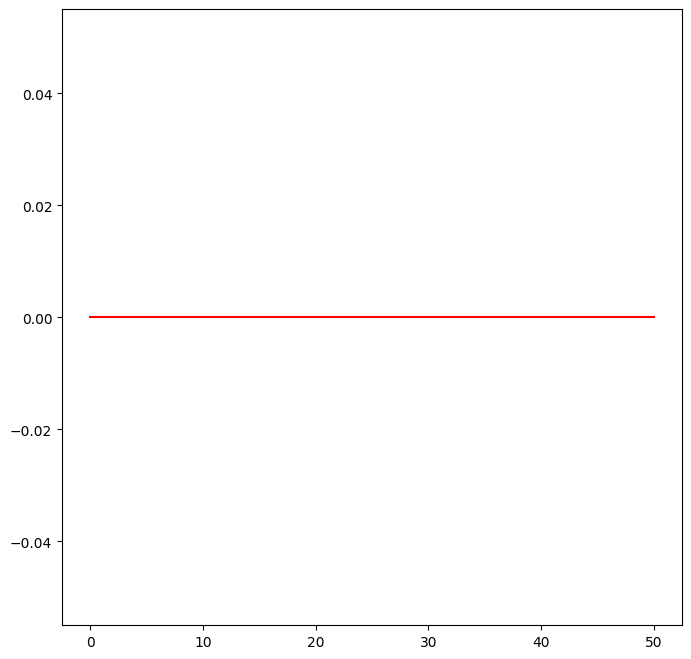

In [13]:
# Lets plot this
plt.figure(figsize=(8, 8))
plt.plot([0, sensor_offset['x']], [0, sensor_offset['y']], 'r-')
for coordinate in sensor_reading_coordinates:
    plt.plot([sensor_offset['x'], coordinate['x']], [sensor_offset['y'], coordinate['y']], 'b--')

In [ ]:
population_size = 20
poses = np.zeros(population_size, dtype=Pose)
rng = np.random.default_rng()
poses['x'] = rng.uniform(0, width, population_size)
poses['y'] = rng.uniform(0, height, population_size)
poses['theta'] = rng.uniform(-np.pi, np.pi, population_size)
poses

array([( 529.132   ,  846.79816 , -1.7750338 ),
       ( 791.6341  , 1107.592   ,  0.5193409 ),
       (  77.6211  , 1324.01    ,  2.8305469 ),
       ( 712.5102  ,   83.10671 , -0.15013705),
       (1403.9518  ,  169.93211 , -0.19450916),
       ( 256.1859  , 1437.0178  , -0.6981825 ),
       (1138.534   ,  138.61815 , -2.1683793 ),
       (1248.1973  , 1374.4004  ,  2.827475  ),
       ( 479.54895 ,  620.5362  ,  1.5932846 ),
       (  75.46078 , 1029.3027  ,  2.3511472 ),
       (1244.1188  , 1054.8557  , -0.4976572 ),
       ( 469.53702 ,  768.0789  , -1.1729043 ),
       ( 669.46674 ,  584.7717  ,  2.2628179 ),
       ( 977.1944  , 1299.4132  , -0.26939252),
       (1134.9432  , 1493.4988  ,  1.2040666 ),
       (1069.2195  , 1256.5548  ,  1.1145549 ),
       ( 110.012856, 1370.5529  ,  2.5537317 ),
       ( 745.3994  ,  800.13965 ,  0.50381327),
       ( 154.09312 ,  198.2442  , -2.957021  ),
       ( 775.05505 ,   40.936844, -0.6032356 )],
      dtype=[('x', '<f4'), ('y', '<f4')

In [ ]:
pose_unit_vectors = np.zeros(population_size, dtype=Vector2D)
pose_unit_vectors['x'] = np.cos(poses['theta'])
pose_unit_vectors['y'] = np.sin(poses['theta'])
pose_unit_vectors

array([(-0.20282057, -0.9792159 ), ( 0.8681465 ,  0.49630803),
       (-0.952014  ,  0.3060544 ), ( 0.9887506 , -0.14957364),
       ( 0.98114264, -0.19328497), ( 0.7660118 , -0.64282656),
       (-0.562646  , -0.82669795), (-0.9510694 ,  0.30897734),
       (-0.02248638,  0.99974716), (-0.7035288 ,  0.7106668 ),
       ( 0.87870336, -0.47736824), ( 0.38747597, -0.9218798 ),
       (-0.638095  ,  0.76995766), ( 0.96393275, -0.2661459 ),
       ( 0.35856453,  0.93350494), ( 0.44057712,  0.89771473),
       (-0.8321288 ,  0.55458236), ( 0.875748  ,  0.4827685 ),
       (-0.98301494, -0.18352547), ( 0.8235043 , -0.56731   )],
      dtype=[('x', '<f4'), ('y', '<f4')])

In [ ]:
# Transform sensor coordinates to world coordinates for each pose
# Start by rotating them
rotated_sensor_coords = np.zeros((population_size, len(sensor_reading_coordinates)), dtype=Vector2D)
rotated_sensor_coords['x'] = sensor_reading_coordinates['x'] * pose_unit_vectors['x'][:, np.newaxis] - sensor_reading_coordinates['y'] * pose_unit_vectors['y'][:, np.newaxis]
rotated_sensor_coords['y'] = sensor_reading_coordinates['x'] * pose_unit_vectors['y'][:, np.newaxis] + sensor_reading_coordinates['y'] * pose_unit_vectors['x'][:, np.newaxis]

# Now translate them
world_sensor_coords = np.zeros((population_size, len(sensor_reading_coordinates)), dtype=Vector2D)
world_sensor_coords['x'] = rotated_sensor_coords['x'] + poses['x'][:, np.newaxis]
world_sensor_coords['y'] = rotated_sensor_coords['y'] + poses['y'][:, np.newaxis]


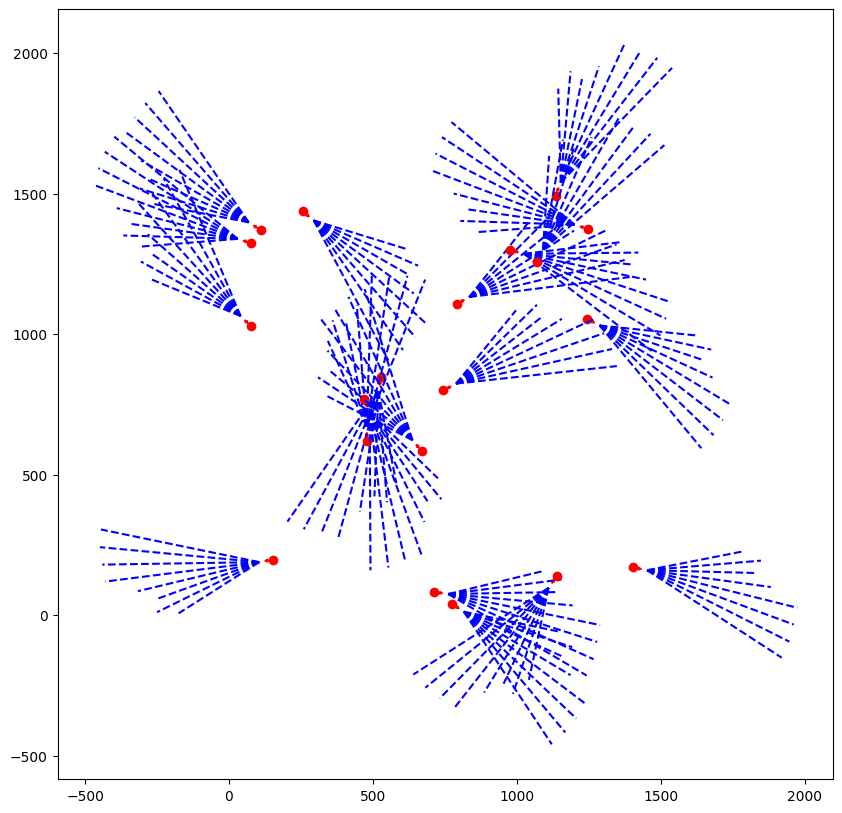

In [ ]:
# Rotated offset is only for plotting purposes
rotated_offsets = np.zeros((population_size,), dtype=Vector2D)
rotated_offsets['x'] = sensor_offset['x'] * pose_unit_vectors['x'] - sensor_offset['y'] * pose_unit_vectors['y']
rotated_offsets['y'] = sensor_offset['x'] * pose_unit_vectors['y'] + sensor_offset['y'] * pose_unit_vectors['x']
# For all poses - plot the pose, and the world sensor coordinates
plt.figure(figsize=(10, 10))
for i in range(population_size):
    plt.plot(poses['x'][i], poses['y'][i], 'ro')  # plot the pose

    plt.arrow(poses['x'][i], poses['y'][i], 
              20 * pose_unit_vectors['x'][i], 20 * pose_unit_vectors['y'][i], 
              head_width=10, head_length=10, fc='r', ec='r')  # plot the orientation

    for j in range(len(sensor_reading_coordinates)):
        plt.plot([poses['x'][i] + rotated_offsets['x'][i], world_sensor_coords['x'][i, j]], 
                 [poses['y'][i] + rotated_offsets['y'][i], world_sensor_coords['y'][i, j]], 'b--')  # plot the sensor rays